In [1]:
from __future__ import absolute_import, unicode_literals, print_function
import numpy
from numpy import pi, cos
from pymultinest.solve import solve
import os
try: os.mkdir('chains')
except OSError: pass

In [2]:
# probability function, taken from the eggbox problem.

def myprior(cube):
	return cube * 10 * pi

def myloglike(cube):
	chi = (cos(cube / 2.)).prod()
	return (2. + chi)**5

# number of dimensions our problem has
parameters = ["x", "y"]
n_params = len(parameters)
# name of the output files
prefix = "chains/3-"

# run MultiNest
result = solve(LogLikelihood=myloglike, Prior=myprior, 
	n_dims=n_params, outputfiles_basename=prefix, verbose=True)

print()
print('evidence: %(logZ).1f +- %(logZerr).1f' % result)
print()
print('parameter values:')
for name, col in zip(parameters, result['samples'].transpose()):
	print('%15s : %.3f +- %.3f' % (name, col.mean(), col.std()))

# make marginal plots by running:
# $ python multinest_marginals.py chains/3-
# For that, we need to store the parameter names:
import json
with open('%sparams.json' % prefix, 'w') as f:
	json.dump(parameters, f, indent=2)

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    2
 resuming from previous job
 *****************************************************
 Starting MultiNest
Acceptance Rate:                        0.592605
Replacements:                               3606
Total Samples:                              6085
Nested Sampling ln(Z):                235.680631
Importance Nested Sampling ln(Z):     236.089721 +/-  0.056013
 ln(ev)=   236.03518436263136      +/-  0.12219543422978060     
  analysing data from chains/3-.txt
 Total Likelihood Evaluations:         6085
 Sampling finished. Exiting MultiNest

evidence: 236.0 +- 0.1

parameter values:
              x : 14.644 +- 8.720
              y : 14.865 +- 8.301


Removed no burn in
Guardado: chains/3-triangle-getdist.png


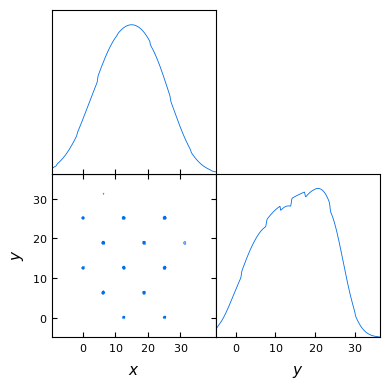

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples

samples = result["samples"]     # (Nsamples, 2)
names   = ["x","y"]             # nombres internos
labels  = ["x","y"]             # << SIN $...$ >>

gds = MCSamples(samples=samples, names=names, labels=labels)

g = plots.getSubplotPlotter()
g.triangle_plot([gds], filled=True)  # sin params => usa ambos
plt.savefig("chains/3-triangle-getdist.png", dpi=150, bbox_inches="tight")
print("Guardado: chains/3-triangle-getdist.png")


## Implementacion para HIIGs

In [4]:
from __future__ import annotations
import os
import json
import numpy as np
from astropy.table import Table
from astropy.cosmology import FlatwCDM

import pymultinest
import matplotlib.pyplot as plt
import corner
from getdist import plots, MCSamples
import scipy.optimize as op

In [6]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0 = theta

    # Parámetros cosmológicos fijos como en tu script
    # (Om, w0) se dejan fijos; Or no se usa explícitamente
    Om = 0.3
    w0 = -1.0
    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)

    ixG = np.where(z > 10)
    ixH = np.where(z < 10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    # Distancia de luminosidad en Mpc -> módulo de distancia
    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    # Tu relación Mu observada/modelo (idéntica a Zeus)
    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2 * W)
    llq = -0.5*xsq
    return llq  # PyMultiNest sólo quiere el log-like

In [7]:
def load_data(dpath):
    # Tu lector (equivalente a h2gdat): toma columnas 2..8 (1-index en tu archivo)
    Tpath = os.path.join(dpath, 'indat/Union2020v16.dat')
    data = Table.read(Tpath, format='ascii', comment='#')

    vix  = np.asarray(data['col1'])
    vx   = np.asarray(data['col2'])
    vy   = np.asarray(data['col3'])
    vz   = np.asarray(data['col4'])
    vxEr = np.asarray(data['col5'])
    vyEr = np.asarray(data['col6'])
    vzEr = np.asarray(data['col7'])
    vsp  = np.asarray(data['col8'])

    # (tu filtro original por LSL=1.83 estaba sobre vx; si lo necesitas, actívalo)
    # LSL = 1.83
    # ix = np.where((vx - vxEr) <= LSL)
    # return vix[ix], vx[ix], vy[ix], vz[ix], vxEr[ix], vyEr[ix], vzEr[ix], vsp[ix]

    return vix, vx, vy, vz, vxEr, vyEr, vzEr, vsp

In [8]:
# ------------------------------
# 2) Prior transform (u in [0,1] -> theta en tus rangos)
#    Matchea exactamente tu lnprior:
#    alpha ~ U[20,40], beta ~ U[0,10], h ~ U[0.5,1.0]
# ------------------------------
def prior_transform(u):
    alpha = 20.0 + 20.0 * u[0]     # 20→40
    beta  =  0.0 + 10.0 * u[1]     # 0→10
    h0    =  0.5 +  0.5 * u[2]     # 0.5→1.0
    return np.array([alpha, beta, h0])

In [11]:
# ------------------------------
# 3) Main
# ------------------------------
if __name__ == "__main__":
    # Ajusta esta ruta a la carpeta de tus datos
    # (en tu Zeus usabas: HOME + '/MCMC/ZEUS/h0wsh2023/dat/')
    HOME = os.path.expanduser("~") + '/HIIGs/'
    dpath = os.path.join(HOME, "MCMC/ZEUS/h0wsh2023/dat/")

    dpath = '/home/hollman/gdrive/DataHII//MCMC/ZEUS/h0wsh2023/dat/'
    print("Data path:", dpath)

    vTg, vx, vy, vz, vxErr, vyErr, vzErr, vsp = load_data(dpath)

    # ---- ML inicial (opcional, sólo diagnóstico)
    def nll(theta):
        return -lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

    res = op.minimize(nll, x0=[32.0, 5.0, 0.75], method="Nelder-Mead")
    print("ML guess:", res.x)

    # ---- Ejecutar PyMultiNest
    outdir = os.path.join(dpath, "results_mnest")
    os.makedirs(outdir, exist_ok=True)
    prefix = os.path.join(outdir, "hii_")

    def loglike_for_mnest(theta):
        return lnlike(theta, vx, vy, vz, vxErr, vyErr, vzErr)

    n_dims = 3
    result = pymultinest.solve(
        LogLikelihood=loglike_for_mnest,
        Prior=prior_transform,
        n_dims=n_dims,
        outputfiles_basename=prefix,
        # Opciones típicas MultiNest:
        evidence_tolerance=0.5,
        n_live_points=600,
        multimodal=True,
        verbose=True
    )

Data path: /home/hollman/gdrive/DataHII//MCMC/ZEUS/h0wsh2023/dat/
ML guess: [33.48268798  4.82632196  0.77453062]
 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  600
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.992366
Replacements:                                650
Total Samples:                               655
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -510.174728 +/-  0.999236
Acceptance Rate:                        0.977654
Replacements:                                700
Total Samples:                               716
Nested Sampling ln(Z):            **************
Importance Nested Sampling ln(Z):    -510.26377

In [13]:
print("\nEvidence lnZ = %.3f ± %.3f" % (result["logZ"], result["logZerr"]))

# Muestras a posteriori (equal-weight) directamente del result:
samples = result["samples"]   # shape = (Nsamples, 3)
parameters = [r"\alpha", r"\beta", r"h"]
print("Posterior means/stdev:")
for name, col in zip(parameters, samples.T):
    print(f"{name:>6s}: {col.mean():.3f} ± {col.std():.3f}")

# Guarda nombres para scripts auxiliares
with open(prefix + "params.json", "w") as f:
    json.dump(parameters, f, indent=2)

# ------------------------------
# 4) Corner plot
# ------------------------------
fig = corner.corner(
    samples,
    labels=[r"$\alpha$", r"$\beta$", r"$h$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84]
)
fig.savefig(prefix + "corner.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Corner guardado en:", prefix + "corner.png")


Evidence lnZ = -447.578 ± 0.137
Posterior means/stdev:
\alpha: 33.479 ± 0.106
 \beta: 4.829 ± 0.086
     h: 0.775 ± 0.039
Corner guardado en: /home/hollman/gdrive/DataHII//MCMC/ZEUS/h0wsh2023/dat/results_mnest/hii_corner.png


Removed no burn in
GetDist triangle en: /home/hollman/gdrive/DataHII//MCMC/ZEUS/h0wsh2023/dat/results_mnest/hii_triangle_getdist.png

Listo. Archivos en: /home/hollman/gdrive/DataHII//MCMC/ZEUS/h0wsh2023/dat/results_mnest


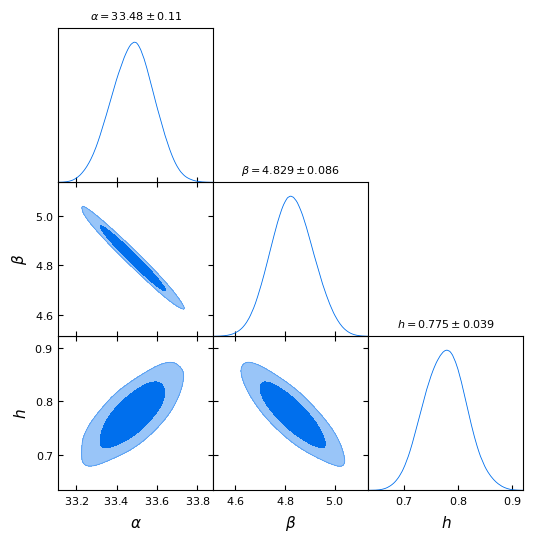

In [14]:
# ------------------------------
# 5) GetDist triangle (recuerda: sin $...$ en labels)
# ------------------------------
gds = MCSamples(
    samples=samples,
    names=["alpha", "beta", "h"],
    labels=[r"\alpha", r"\beta", r"h"]  # SIN '$', GetDist los añade
)
g = plots.getSubplotPlotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gds], filled=True, title_limit=1)
g.export(prefix + "triangle_getdist.png")
print("GetDist triangle en:", prefix + "triangle_getdist.png")

print("\nListo. Archivos en:", outdir)